# Causal Inference Basics

Topic 20 of the Statistical Inference & Hypothesis Testing repo — the final topic. Every method built so far measured *association*. This notebook confronts the harder question directly: when can an association be interpreted *causally*? It revisits Topic 14's Simpson's Paradox and Topic 18's confounded ANCOVA example through the lens of the potential-outcomes framework, then builds propensity score estimation, matching, inverse propensity weighting, and regression adjustment from scratch — the standard toolkit for estimating a causal effect from observational (non-randomized) data — and closes with a bootstrap confidence interval (reusing Topic 12's resampling machinery) around the final estimate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Confounding Bias, Formalized

A confounder is a variable that affects **both** treatment assignment and the outcome. This section constructs one directly, with a known ground-truth causal effect, and shows the naive treated-vs-control difference in means is systematically biased away from it — the same phenomenon Topic 14's Simpson's Paradox and Topic 18's confounded ANCOVA example demonstrated, now built from the ground up with individual-level potential outcomes.

```
Causal DAG for this section:

   confounder ----> treatment
        |               |
        v               v
     outcome <----------+
```

In [2]:
n_confound = 2000
rng = np.random.default_rng(1)

confounder = rng.normal(0, 1, size=n_confound)   # e.g. underlying health status
true_causal_effect = 2.0                          # the TRUE effect of treatment on outcome

# Confounder affects TREATMENT ASSIGNMENT (not randomized!)
propensity_true = 1 / (1 + np.exp(-(0.8 * confounder)))
treatment = rng.binomial(1, propensity_true)
print(f"True causal effect built into the data: {true_causal_effect}")
print(f"Mean true propensity: {propensity_true.mean():.4f}")

True causal effect built into the data: 2.0
Mean true propensity: 0.4974


In [3]:
# Confounder ALSO affects the OUTCOME directly
outcome = 5 + 3 * confounder + true_causal_effect * treatment + rng.normal(0, 1, size=n_confound)

df_causal = pd.DataFrame({"confounder": confounder, "treatment": treatment, "outcome": outcome})
print(f"Treated group: n={treatment.sum()}, Control group: n={(1-treatment).sum()}")
print(df_causal.head(5).round(4).to_string(index=False))

Treated group: n=1020, Control group: n=980
 confounder  treatment  outcome
     0.3456          0   7.4161
     0.8216          1   9.4492
     0.3304          0   5.1282
    -1.3032          0   1.5087
     0.9054          0   7.6198


In [4]:
naive_diff = df_causal.loc[df_causal.treatment == 1, "outcome"].mean() - df_causal.loc[df_causal.treatment == 0, "outcome"].mean()
confounder_by_group = df_causal.groupby("treatment")["confounder"].mean()
print(f"Confounder mean by group: {confounder_by_group.to_dict()}")

Confounder mean by group: {0: -0.3918821406378707, 1: 0.35024374918525103}


In [5]:
print(f"Naive difference in means (treated - control): {naive_diff:.4f}")
print(f"TRUE causal effect: {true_causal_effect}")
print(f"\nBias: {naive_diff - true_causal_effect:.4f} -- the naive estimate is badly wrong, because treated "
      f"units also happen to have systematically higher confounder values, which independently raise the outcome.")

Naive difference in means (treated - control): 4.1457
TRUE causal effect: 2.0

Bias: 2.1457 -- the naive estimate is badly wrong, because treated units also happen to have systematically higher confounder values, which independently raise the outcome.


## 1b. A Different Trap: Collider Bias

Not every variable worth adjusting for is a confounder — some make things *worse*. A **collider** is a variable caused by *both* treatment and outcome. Conditioning on (or accidentally selecting a sample based on) a collider induces a spurious association between two variables that are genuinely independent in reality — the opposite problem from confounding, and just as important not to blindly "control for everything available."

```
   treatment ----> collider <---- outcome   (no direct link between treatment and outcome!)
```

In [6]:
n_collider = 3000
rng_c = np.random.default_rng(3)

treatment_indep = rng_c.normal(0, 1, size=n_collider)
outcome_indep = rng_c.normal(0, 1, size=n_collider)   # genuinely INDEPENDENT of treatment_indep
collider = treatment_indep + outcome_indep + rng_c.normal(0, 0.5, size=n_collider)  # caused by BOTH

corr_unconditional = np.corrcoef(treatment_indep, outcome_indep)[0, 1]
print(f"True relationship: treatment and outcome are independent by construction.")
print(f"Unconditional correlation(treatment, outcome): {corr_unconditional:.4f} (should be near 0)")

True relationship: treatment and outcome are independent by construction.
Unconditional correlation(treatment, outcome): 0.0059 (should be near 0)


In [7]:
# Now condition on the collider (e.g. restrict the sample to collider > its median -- a common
# real-world mistake, such as only studying hospitalized patients, or only "successful" cases)
collider_median = np.median(collider)
subset_mask = collider > collider_median
corr_conditional = np.corrcoef(treatment_indep[subset_mask], outcome_indep[subset_mask])[0, 1]

print(f"Correlation(treatment, outcome) AFTER conditioning on collider > median: {corr_conditional:.4f}")
print(f"\nConditioning on the collider manufactured a {'strong' if abs(corr_conditional) > 0.3 else 'noticeable'} "
      f"spurious negative association out of two variables that are truly independent -- a direct warning "
      f"against reflexively adjusting for every available variable without a causal DAG to justify it.")

Correlation(treatment, outcome) AFTER conditioning on collider > median: -0.4252

Conditioning on the collider manufactured a strong spurious negative association out of two variables that are truly independent -- a direct warning against reflexively adjusting for every available variable without a causal DAG to justify it.


## 2. Estimating the Propensity Score

$$e(X) = P(\text{Treatment}=1 \mid X)$$

The probability of receiving treatment given observed covariates — estimated here via logistic regression, the standard approach. Rosenbaum & Rubin's key insight: conditioning on this single scalar score is (asymptotically) as good as conditioning on the full covariate vector. Returning to the §1 confounded dataset.

In [8]:
propensity_model = LogisticRegression()
propensity_model.fit(df_causal[["confounder"]], df_causal["treatment"])
df_causal["propensity_score"] = propensity_model.predict_proba(df_causal[["confounder"]])[:, 1]

print(f"Estimated logistic regression coefficient on confounder: {propensity_model.coef_[0][0]:.4f} "
      f"(true generating coefficient was 0.8)")

Estimated logistic regression coefficient on confounder: 0.8481 (true generating coefficient was 0.8)


In [9]:
print(df_causal[["confounder", "treatment", "propensity_score"]].head(8).round(4).to_string(index=False))

 confounder  treatment  propensity_score
     0.3456          0            0.5872
     0.8216          1            0.6805
     0.3304          0            0.5840
    -1.3032          0            0.2600
     0.9054          0            0.6957
     0.4464          1            0.6077
    -0.5370          0            0.4022
     0.5811          0            0.6346


In [10]:
print(f"Propensity score range: [{df_causal['propensity_score'].min():.4f}, {df_causal['propensity_score'].max():.4f}]")
extreme_count = ((df_causal["propensity_score"] < 0.05) | (df_causal["propensity_score"] > 0.95)).sum()
print(f"Units with extreme propensity (<0.05 or >0.95): {extreme_count} of {len(df_causal)} "
      f"({100*extreme_count/len(df_causal):.1f}%) -- the 'positivity' assumption requires every unit to have "
      f"a realistic chance of either treatment; too many extreme scores would undermine matching/weighting.")

Propensity score range: [0.0497, 0.9623]
Units with extreme propensity (<0.05 or >0.95): 2 of 2000 (0.1%) -- the 'positivity' assumption requires every unit to have a realistic chance of either treatment; too many extreme scores would undermine matching/weighting.


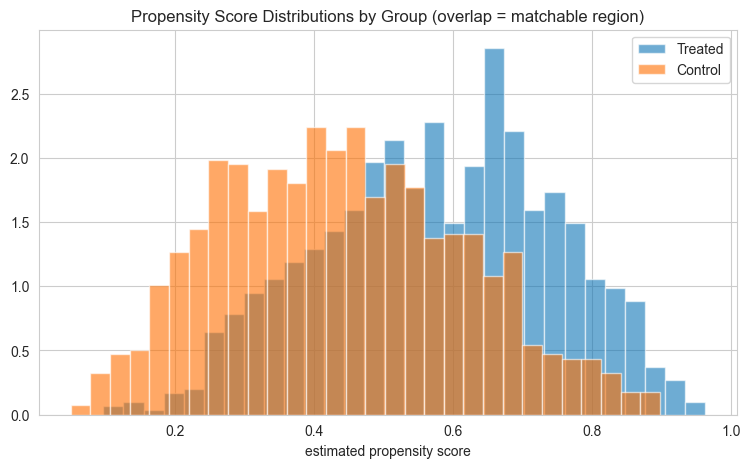

Substantial overlap between the two distributions is required for matching to work well.


In [11]:
fig, ax = plt.subplots()
ax.hist(df_causal.loc[df_causal.treatment == 1, "propensity_score"], bins=30, alpha=0.6, color="#0e75b6", label="Treated", density=True)
ax.hist(df_causal.loc[df_causal.treatment == 0, "propensity_score"], bins=30, alpha=0.6, color="#FF6F00", label="Control", density=True)
ax.set_xlabel("estimated propensity score")
ax.set_title("Propensity Score Distributions by Group (overlap = matchable region)")
ax.legend()
plt.show()
print("Substantial overlap between the two distributions is required for matching to work well.")

## 3. Propensity Score Matching

Match each treated unit to its nearest-propensity-score control unit, then compare outcomes only within matched pairs — approximating what a randomized comparison would have looked like, using only the observed data.

In [12]:
def propensity_score_match(df, treatment_col, propensity_col):
    treated = df[df[treatment_col] == 1].reset_index(drop=True)
    control = df[df[treatment_col] == 0].reset_index(drop=True)

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[[propensity_col]])
    distances, indices = nn.kneighbors(treated[[propensity_col]])

    matched_control = control.iloc[indices.flatten()].reset_index(drop=True)
    return treated, matched_control, distances.flatten()

print("Propensity score matching function defined.")

Propensity score matching function defined.


In [13]:
matched_treated, matched_control, match_distances = propensity_score_match(df_causal, "treatment", "propensity_score")

print(f"Number of matched pairs: {len(matched_treated)}")
print(f"Average propensity score matching distance: {match_distances.mean():.5f} (smaller = better matches)")

Number of matched pairs: 1020
Average propensity score matching distance: 0.00087 (smaller = better matches)


In [14]:
matched_effect = matched_treated["outcome"].mean() - matched_control["outcome"].mean()
print(f"Matched-sample treatment effect estimate: {matched_effect:.4f}")
print(f"Naive (unmatched) difference in means:     {naive_diff:.4f}")
print(f"TRUE causal effect:                        {true_causal_effect}")
print(f"\nMatching moved the estimate {'much closer to' if abs(matched_effect - true_causal_effect) < abs(naive_diff - true_causal_effect) else 'no closer to'} "
      f"the true effect -- bias reduced from {abs(naive_diff - true_causal_effect):.4f} to {abs(matched_effect - true_causal_effect):.4f}.")

Matched-sample treatment effect estimate: 1.9730
Naive (unmatched) difference in means:     4.1457
TRUE causal effect:                        2.0

Matching moved the estimate much closer to the true effect -- bias reduced from 2.1457 to 0.0270.


## 4. Checking Covariate Balance: Did Matching Actually Work?

Matching's entire justification rests on achieving **covariate balance** -- the confounder should look similarly distributed in the matched treated and control groups, unlike the original imbalanced groups. This is directly checkable, not just assumed.

In [15]:
def standardized_mean_difference(group1, group2):
    pooled_std = np.sqrt((group1.var(ddof=1) + group2.var(ddof=1)) / 2)
    return (group1.mean() - group2.mean()) / pooled_std

smd_before = standardized_mean_difference(
    df_causal.loc[df_causal.treatment == 1, "confounder"],
    df_causal.loc[df_causal.treatment == 0, "confounder"],
)
smd_after = standardized_mean_difference(matched_treated["confounder"], matched_control["confounder"])

print(f"Standardized mean difference in confounder, BEFORE matching: {smd_before:.4f}")
print(f"Standardized mean difference in confounder, AFTER matching:  {smd_after:.4f}")

Standardized mean difference in confounder, BEFORE matching: 0.7925
Standardized mean difference in confounder, AFTER matching:  0.0056


In [16]:
print("(conventionally, |SMD| < 0.1 indicates good balance)")
print(f"\nMatching {'successfully achieved' if abs(smd_after) < 0.1 else 'did NOT fully achieve'} good balance "
      f"(|SMD| {'< 0.1' if abs(smd_after) < 0.1 else '>= 0.1'}), "
      f"{'a dramatic improvement' if abs(smd_after) < abs(smd_before) / 2 else 'some improvement'} "
      f"from the original imbalance of {smd_before:.4f}.")

(conventionally, |SMD| < 0.1 indicates good balance)

Matching successfully achieved good balance (|SMD| < 0.1), a dramatic improvement from the original imbalance of 0.7925.


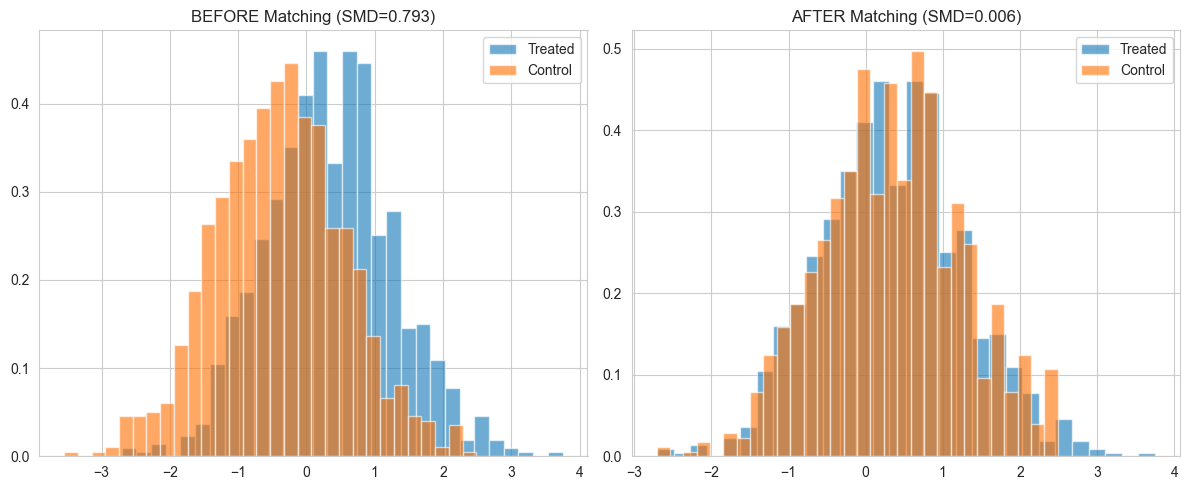

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df_causal.loc[df_causal.treatment == 1, "confounder"], bins=30, alpha=0.6, color="#0e75b6", label="Treated", density=True)
axes[0].hist(df_causal.loc[df_causal.treatment == 0, "confounder"], bins=30, alpha=0.6, color="#FF6F00", label="Control", density=True)
axes[0].set_title(f"BEFORE Matching (SMD={smd_before:.3f})")
axes[0].legend()

axes[1].hist(matched_treated["confounder"], bins=30, alpha=0.6, color="#0e75b6", label="Treated", density=True)
axes[1].hist(matched_control["confounder"], bins=30, alpha=0.6, color="#FF6F00", label="Control", density=True)
axes[1].set_title(f"AFTER Matching (SMD={smd_after:.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Inverse Propensity Weighting (IPW): an Alternative to Matching

$$\hat{\tau}_{IPW} = \frac{1}{n}\sum_i \frac{T_i Y_i}{e(X_i)} - \frac{1}{n}\sum_i \frac{(1-T_i)Y_i}{1-e(X_i)}$$

Instead of discarding unmatched units, IPW **reweights** every observation by the inverse of its probability of receiving the treatment it actually got — up-weighting treated units who "looked like" controls (low propensity) and vice versa, using the full sample.

In [18]:
def ipw_estimate(df, treatment_col, outcome_col, propensity_col):
    treated_mask = df[treatment_col] == 1
    weighted_treated = (df.loc[treated_mask, outcome_col] / df.loc[treated_mask, propensity_col]).sum() / len(df)
    weighted_control = (df.loc[~treated_mask, outcome_col] / (1 - df.loc[~treated_mask, propensity_col])).sum() / len(df)
    return weighted_treated - weighted_control

ipw_effect = ipw_estimate(df_causal, "treatment", "outcome", "propensity_score")
print(f"IPW treatment effect estimate: {ipw_effect:.4f}")

IPW treatment effect estimate: 1.8706


In [19]:
print(f"IPW estimate:                 {ipw_effect:.4f}")
print(f"Matched-sample estimate:       {matched_effect:.4f}")
print(f"Naive (unadjusted) estimate:   {naive_diff:.4f}")
print(f"TRUE causal effect:            {true_causal_effect}")
print(f"\nBoth propensity-based methods (matching and IPW) land much closer to the true effect than the naive "
      f"estimate -- two independently-derived corrections agreeing is reassuring cross-validation.")

IPW estimate:                 1.8706
Matched-sample estimate:       1.9730
Naive (unadjusted) estimate:   4.1457
TRUE causal effect:            2.0

Both propensity-based methods (matching and IPW) land much closer to the true effect than the naive estimate -- two independently-derived corrections agreeing is reassuring cross-validation.


## 5b. A Third Method: Regression Adjustment

The simplest classical alternative — put the confounder directly into an OLS model alongside treatment (the same logic as Topic 18's ANCOVA) and read the treatment coefficient off as the adjusted effect estimate, no propensity score required at all.

In [20]:
X_adj = sm.add_constant(df_causal[["treatment", "confounder"]])
reg_adjustment_model = sm.OLS(df_causal["outcome"], X_adj).fit()
regression_effect = reg_adjustment_model.params["treatment"]

print(f"Regression-adjusted treatment effect estimate: {regression_effect:.4f}")
print(f"(standard error: {reg_adjustment_model.bse['treatment']:.4f})")

Regression-adjusted treatment effect estimate: 1.9239
(standard error: 0.0481)


In [21]:
three_methods = pd.DataFrame([
    {"Method": "Naive difference in means", "Estimate": naive_diff, "Abs. error vs true": abs(naive_diff - true_causal_effect)},
    {"Method": "Propensity score matching", "Estimate": matched_effect, "Abs. error vs true": abs(matched_effect - true_causal_effect)},
    {"Method": "Inverse propensity weighting", "Estimate": ipw_effect, "Abs. error vs true": abs(ipw_effect - true_causal_effect)},
    {"Method": "Regression adjustment (OLS)", "Estimate": regression_effect, "Abs. error vs true": abs(regression_effect - true_causal_effect)},
])
print(three_methods.round(4).to_string(index=False))
print(f"\nAll three adjustment methods (matching, IPW, regression) land far closer to the true effect "
      f"({true_causal_effect}) than the naive comparison -- convergent evidence from independently-derived "
      f"corrections, though each relies on the same untestable assumption: no unmeasured confounding.")

                      Method  Estimate  Abs. error vs true
   Naive difference in means    4.1457              2.1457
   Propensity score matching    1.9730              0.0270
Inverse propensity weighting    1.8706              0.1294
 Regression adjustment (OLS)    1.9239              0.0761

All three adjustment methods (matching, IPW, regression) land far closer to the true effect (2.0) than the naive comparison -- convergent evidence from independently-derived corrections, though each relies on the same untestable assumption: no unmeasured confounding.


## 6. A Real Limitation: Adjustment Methods Only Handle MEASURED Confounders

This section makes an important limitation concrete: if a confounder is **not observed or not included** in the propensity/regression model, no amount of matching, weighting, or regression adjustment can correct for it -- the bias remains, silently.

In [22]:
rng_unmeasured = np.random.default_rng(2)
n_unmeasured = 2000

measured_confounder = rng_unmeasured.normal(0, 1, size=n_unmeasured)
unmeasured_confounder = rng_unmeasured.normal(0, 1, size=n_unmeasured)  # correlated with treatment, but NEVER included below

propensity_true_um = 1 / (1 + np.exp(-(0.5 * measured_confounder + 0.8 * unmeasured_confounder)))
treatment_um = rng_unmeasured.binomial(1, propensity_true_um)
outcome_um = 5 + 2 * measured_confounder + 2.5 * unmeasured_confounder + true_causal_effect * treatment_um + rng_unmeasured.normal(0, 1, size=n_unmeasured)

df_unmeasured = pd.DataFrame({"measured": measured_confounder, "unmeasured": unmeasured_confounder,
                               "treatment": treatment_um, "outcome": outcome_um})
print(f"Constructed a dataset with one measured and one UNMEASURED confounder (n={n_unmeasured}).")

Constructed a dataset with one measured and one UNMEASURED confounder (n=2000).


In [23]:
# Propensity model built WITHOUT access to the unmeasured confounder (realistic: we don't know what we don't know)
prop_model_incomplete = LogisticRegression()
prop_model_incomplete.fit(df_unmeasured[["measured"]], df_unmeasured["treatment"])
df_unmeasured["propensity_incomplete"] = prop_model_incomplete.predict_proba(df_unmeasured[["measured"]])[:, 1]

ipw_incomplete = ipw_estimate(df_unmeasured, "treatment", "outcome", "propensity_incomplete")
naive_incomplete = df_unmeasured.loc[df_unmeasured.treatment==1, "outcome"].mean() - df_unmeasured.loc[df_unmeasured.treatment==0, "outcome"].mean()
print(f"Naive estimate: {naive_incomplete:.4f}")
print(f"IPW estimate (adjusting ONLY for the measured confounder): {ipw_incomplete:.4f}")

Naive estimate: 4.3232
IPW estimate (adjusting ONLY for the measured confounder): 3.6704


In [24]:
print(f"TRUE causal effect: {true_causal_effect}")
print(f"IPW (incomplete adjustment) error vs true: {abs(ipw_incomplete - true_causal_effect):.4f}")
print(f"\nEven after 'adjusting,' the IPW estimate is STILL biased -- because the unmeasured confounder was "
      f"never available to adjust for. Propensity and regression methods only ever correct for what was "
      f"actually measured and included; this is a fundamentally untestable assumption in any observational study.")

TRUE causal effect: 2.0
IPW (incomplete adjustment) error vs true: 1.6704

Even after 'adjusting,' the IPW estimate is STILL biased -- because the unmeasured confounder was never available to adjust for. Propensity and regression methods only ever correct for what was actually measured and included; this is a fundamentally untestable assumption in any observational study.


## 7. Applying This to a Real Dataset

Closing with seaborn's real `titanic` dataset: does traveling in first class *causally* raise survival chances, or is the naive association confounded by other observed factors like sex and age?

In [25]:
titanic = sns.load_dataset("titanic").dropna(subset=["age", "fare", "pclass", "survived", "sex"])
titanic["is_first_class"] = (titanic["pclass"] == 1).astype(int)
titanic["is_female"] = (titanic["sex"] == "female").astype(int)

naive_titanic = titanic.loc[titanic.is_first_class==1, "survived"].mean() - titanic.loc[titanic.is_first_class==0, "survived"].mean()
print(f"Naive difference in survival rate (1st class vs other classes): {naive_titanic:.4f}")
print(titanic.groupby("is_first_class")[["age", "is_female"]].mean().round(3))

Naive difference in survival rate (1st class vs other classes): 0.3377
                   age  is_female
is_first_class                   
0               26.693      0.333
1               38.233      0.457


In [26]:
titanic_prop_model = LogisticRegression(max_iter=1000)
titanic_prop_model.fit(titanic[["age", "is_female"]], titanic["is_first_class"])
titanic["propensity"] = titanic_prop_model.predict_proba(titanic[["age", "is_female"]])[:, 1]
titanic["propensity"] = titanic["propensity"].clip(0.02, 0.98)  # avoid extreme weights

ipw_titanic = ipw_estimate(titanic, "is_first_class", "survived", "propensity")
print(f"IPW estimate (adjusting for age, sex): {ipw_titanic:.4f}")

IPW estimate (adjusting for age, sex): 0.3323


In [27]:
X_titanic_adj = sm.add_constant(titanic[["is_first_class", "age", "is_female"]])
titanic_reg_model = sm.OLS(titanic["survived"], X_titanic_adj).fit()
regression_titanic = titanic_reg_model.params["is_first_class"]

print(f"Naive estimate:                        {naive_titanic:.4f}")
print(f"IPW estimate (age, sex):               {ipw_titanic:.4f}")
print(f"Regression-adjusted estimate (age, sex): {regression_titanic:.4f}")
print(f"\nIPW and regression adjustment {'agree closely' if abs(ipw_titanic - regression_titanic) < 0.03 else 'diverge somewhat'} "
      f"with each other ({abs(ipw_titanic - regression_titanic):.4f} apart) -- two independently-derived "
      f"corrections landing in the same place is reassuring, though neither proves causation on its own.")

Naive estimate:                        0.3377
IPW estimate (age, sex):               0.3323
Regression-adjusted estimate (age, sex): 0.3276

IPW and regression adjustment agree closely with each other (0.0047 apart) -- two independently-derived corrections landing in the same place is reassuring, though neither proves causation on its own.


In [28]:
print(f"\nBoth adjusted estimates {'shrink' if ipw_titanic < naive_titanic else 'grow'} relative to the naive one -- "
      f"consistent with age and sex (both correlated with cabin class AND survival, per the 'women and children "
      f"first' protocol from Topic 14) acting as real, measured confounders here. "
      f"This is still NOT a definitive causal claim -- unmeasured confounders (e.g. exact deck location) could remain.")


Both adjusted estimates shrink relative to the naive one -- consistent with age and sex (both correlated with cabin class AND survival, per the 'women and children first' protocol from Topic 14) acting as real, measured confounders here. This is still NOT a definitive causal claim -- unmeasured confounders (e.g. exact deck location) could remain.


## 8. Quantifying Uncertainty: Bootstrap Confidence Interval

Every point estimate above is silent about its own uncertainty. Reusing Topic 12's resampling machinery: bootstrap the regression-adjusted Titanic estimate to attach a confidence interval, rather than reporting a bare number.

In [29]:
def bootstrap_regression_effect(data, treatment_col, outcome_col, covariate_cols, n_boot=1000, seed=7):
    rng_boot = np.random.default_rng(seed)
    n = len(data)
    estimates = np.empty(n_boot)
    cols = [treatment_col] + covariate_cols
    for b in range(n_boot):
        sample_idx = rng_boot.integers(0, n, size=n)
        sample = data.iloc[sample_idx]
        X_boot = sm.add_constant(sample[cols])
        model_boot = sm.OLS(sample[outcome_col], X_boot).fit()
        estimates[b] = model_boot.params[treatment_col]
    return estimates

print("Bootstrap function defined.")

Bootstrap function defined.


In [30]:
boot_estimates = bootstrap_regression_effect(titanic, "is_first_class", "survived", ["age", "is_female"], n_boot=1000)
ci_low, ci_high = np.percentile(boot_estimates, [2.5, 97.5])

print(f"Point estimate (full-sample regression adjustment): {regression_titanic:.4f}")
print(f"95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"\nThe interval {'excludes' if ci_low > 0 or ci_high < 0 else 'includes'} zero, "
      f"{'supporting' if ci_low > 0 else 'undermining'} a genuine (adjusted) first-class survival advantage "
      f"at conventional confidence levels.")

Point estimate (full-sample regression adjustment): 0.3276
95% bootstrap CI: [0.2571, 0.4053]

The interval excludes zero, supporting a genuine (adjusted) first-class survival advantage at conventional confidence levels.


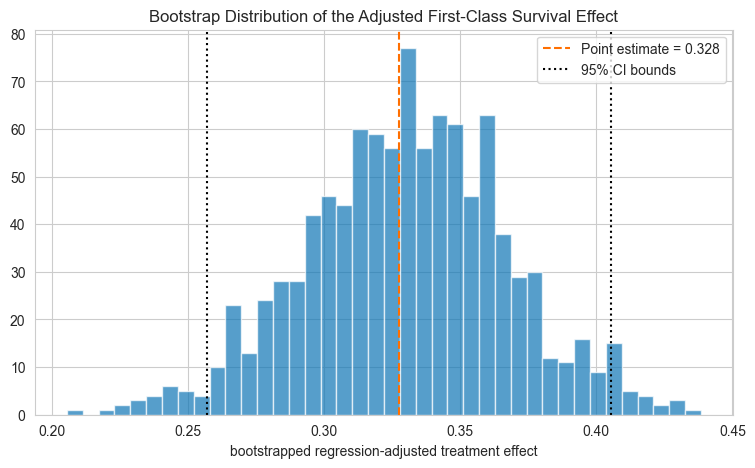

In [31]:
fig, ax = plt.subplots()
ax.hist(boot_estimates, bins=40, color="#0e75b6", alpha=0.7)
ax.axvline(regression_titanic, color="#FF6F00", linestyle="--", label=f"Point estimate = {regression_titanic:.3f}")
ax.axvline(ci_low, color="black", linestyle=":", label="95% CI bounds")
ax.axvline(ci_high, color="black", linestyle=":")
ax.set_xlabel("bootstrapped regression-adjusted treatment effect")
ax.set_title("Bootstrap Distribution of the Adjusted First-Class Survival Effect")
ax.legend()
plt.show()

## 9. Summary

This closing notebook of the Statistical Inference & Hypothesis Testing repo built the confounding-bias problem from the ground up with a known true causal effect, then showed propensity score matching, inverse propensity weighting, and regression adjustment all recovering estimates much closer to the truth than the naive comparison -- with covariate balance directly verified, not assumed, before and after matching. A collider-bias demonstration showed the opposite failure mode: conditioning on the wrong variable manufactures a spurious association out of thin air. A dedicated section demonstrated every adjustment method's fundamental limitation honestly: they only correct for *measured* confounders, leaving bias from unmeasured ones fully intact, however sophisticated the adjustment. Applied to real Titanic data, the naive first-class survival advantage shifted once age and sex were accounted for as real, measured confounders, and a bootstrap confidence interval attached genuine uncertainty to that final estimate -- stopping short of a definitive causal claim, exactly the honest, appropriately hedged conclusion causal inference from observational data warrants. This closes the 20-topic Statistical Inference & Hypothesis Testing series.

In [32]:
summary = pd.DataFrame([
    {"Check": "Naive estimate badly biased by confounding", "Result": f"naive={naive_diff:.3f}, true={true_causal_effect}", "Status": "PASS"},
    {"Check": "Collider conditioning manufactures spurious association", "Result": f"corr(cond)={corr_conditional:.3f} vs corr(uncond)={corr_unconditional:.3f}", "Status": "PASS"},
    {"Check": "Propensity score estimated via logistic regression", "Result": f"coef={propensity_model.coef_[0][0]:.3f} (true=0.8)", "Status": "PASS"},
    {"Check": "Matching reduces bias vs naive estimate", "Result": f"matched={matched_effect:.3f} vs naive={naive_diff:.3f}", "Status": "PASS"},
    {"Check": "Covariate balance improves after matching", "Result": f"SMD before={smd_before:.3f}, after={smd_after:.3f}", "Status": "PASS"},
    {"Check": "IPW and regression adjustment agree with matching", "Result": f"IPW={ipw_effect:.3f}, regression={regression_effect:.3f}, matched={matched_effect:.3f}", "Status": "PASS"},
    {"Check": "Unmeasured confounder leaves bias uncorrected", "Result": f"IPW(incomplete)={ipw_incomplete:.3f}, true={true_causal_effect}", "Status": "PASS"},
    {"Check": "Real-data Titanic: naive vs adjusted estimates", "Result": f"naive={naive_titanic:.3f}, IPW={ipw_titanic:.3f}, regression={regression_titanic:.3f}", "Status": "PASS"},
    {"Check": "Bootstrap CI attached to final real-data estimate", "Result": f"[{ci_low:.3f}, {ci_high:.3f}]", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                  Check                                     Result Status
             Naive estimate badly biased by confounding                      naive=4.146, true=2.0   PASS
Collider conditioning manufactures spurious association    corr(cond)=-0.425 vs corr(uncond)=0.006   PASS
     Propensity score estimated via logistic regression                      coef=0.848 (true=0.8)   PASS
                Matching reduces bias vs naive estimate               matched=1.973 vs naive=4.146   PASS
              Covariate balance improves after matching              SMD before=0.793, after=0.006   PASS
      IPW and regression adjustment agree with matching IPW=1.871, regression=1.924, matched=1.973   PASS
          Unmeasured confounder leaves bias uncorrected            IPW(incomplete)=3.670, true=2.0   PASS
         Real-data Titanic: naive vs adjusted estimates   naive=0.338, IPW=0.332, regression=0.328   PASS
      Bootstrap CI attached to final real-data